<a href="https://colab.research.google.com/github/jananiksaagash-rgb/AppliedAI/blob/main/Ex9a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-30 143921.png to Screenshot 2026-03-30 143921 (1).png


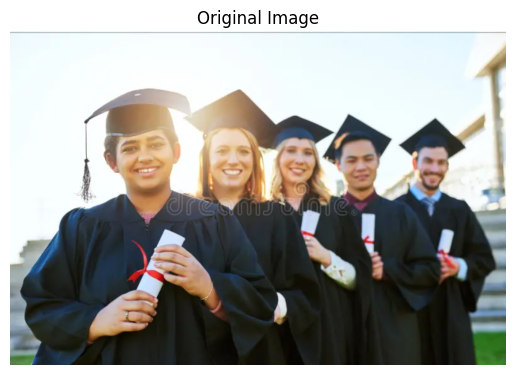

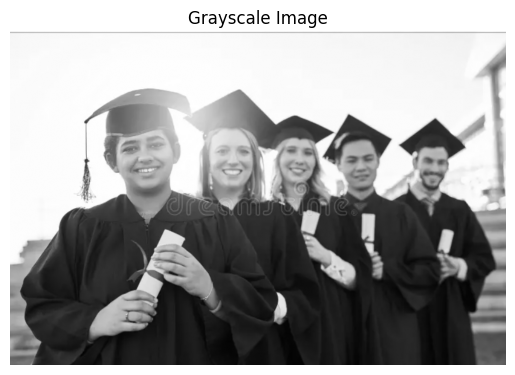

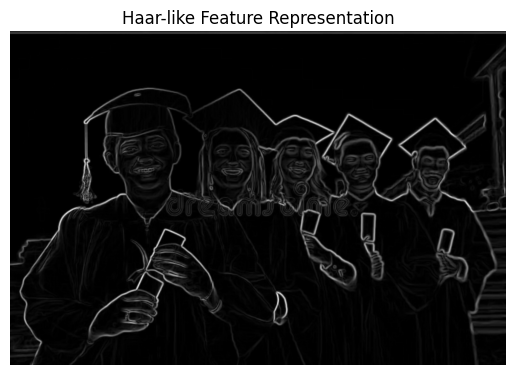

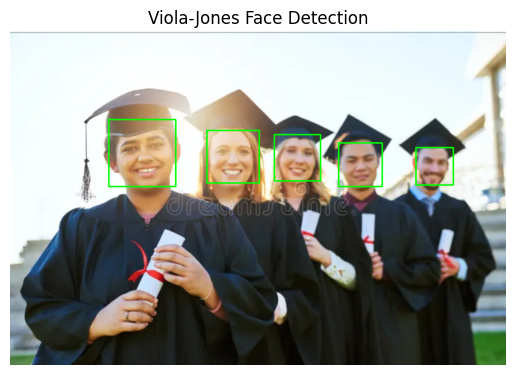

Number of faces detected: 5


In [10]:
# Install
!pip install opencv-python matplotlib -q

import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ===============================
# Original Image
# ===============================
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ===============================
#  Grayscale Image
# ===============================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# ===============================
# Haar Feature Visualization
# ===============================
# Simulating Haar features using edge-like contrast regions
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

haar_like = cv2.magnitude(sobelx, sobely)

plt.imshow(haar_like, cmap='gray')
plt.title("Haar-like Feature Representation")
plt.axis("off")
plt.show()

# ===============================
# Face Detection (Viola-Jones)
# ===============================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Draw bounding boxes
output = image_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(output, (x, y), (x+w, y+h), (0,255,0), 2)

# ===============================
# Final Output
# ===============================
plt.imshow(output)
plt.title("Viola-Jones Face Detection")
plt.axis("off")
plt.show()

# Count only
print(f"Number of faces detected: {len(faces)}")